In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Data Preparation**

In [ ]:
df_raw = pd.read_csv("smoking-dataset.csv")

In [ ]:
df_raw.head()

,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),systolic,relaxation,...,HDL,LDL,hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,dental caries,smoking
0,35,170,85,97.0,0.9,0.9,1,1,118,78,...,70,142,19.8,1,1.0,61,115,125,1,1
1,20,175,110,110.0,0.7,0.9,1,1,119,79,...,71,114,15.9,1,1.1,19,25,30,1,0
2,45,155,65,86.0,0.9,0.9,1,1,110,80,...,57,112,13.7,3,0.6,1090,1400,276,0,0
3,45,165,80,94.0,0.8,0.7,1,1,158,88,...,46,91,16.9,1,0.9,32,36,36,0,0
4,20,165,60,81.0,1.5,0.1,1,1,109,64,...,47,92,14.9,1,1.2,26,28,15,0,0


In [ ]:
df_raw.describe()

,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),systolic,relaxation,...,HDL,LDL,hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,dental caries,smoking
count,38984.000000,38984.000000,38984.000000,38984.000000,38984.000000,38984.000000,38984.000000,38984.000000,38984.000000,38984.000000,...,38984.000000,38984.000000,38984.000000,38984.000000,38984.000000,38984.000000,38984.000000,38984.000000,38984.000000,38984.000000
mean,44.127591,164.689488,65.938718,82.062115,1.014955,1.008768,1.025369,1.026190,121.475631,75.994408,...,57.293146,115.081495,14.624264,1.086523,0.886030,26.198235,27.145188,39.905038,0.214421,0.367279
std,12.063564,9.187507,12.896581,9.326798,0.498527,0.493813,0.157246,0.159703,13.643521,9.658734,...,14.617822,42.883163,1.566528,0.402107,0.220621,19.175595,31.309945,49.693843,0.410426,0.482070
min,20.000000,130.000000,30.000000,51.000000,0.100000,0.100000,1.000000,1.000000,71.000000,40.000000,...,4.000000,1.000000,4.900000,1.000000,0.100000,6.000000,1.000000,2.000000,0.000000,0.000000
25%,40.000000,160.000000,55.000000,76.000000,0.800000,0.800000,1.000000,1.000000,112.000000,70.000000,...,47.000000,91.000000,13.600000,1.000000,0.800000,19.000000,15.000000,17.000000,0.000000,0.000000
50%,40.000000,165.000000,65.000000,82.000000,1.000000,1.000000,1.000000,1.000000,120.000000,76.000000,...,55.000000,113.000000,14.800000,1.000000,0.900000,23.000000,21.000000,26.000000,0.000000,0.000000
75%,55.000000,170.000000,75.000000,88.000000,1.200000,1.200000,1.000000,1.000000,130.000000,82.000000,...,66.000000,136.000000,15.800000,1.000000,1.000000,29.000000,31.000000,44.000000,0.000000,1.000000
max,85.000000,190.000000,135.000000,129.000000,9.900000,9.900000,2.000000,2.000000,233.000000,146.000000,...,359.000000,1860.000000,21.100000,6.000000,11.600000,1090.000000,2914.000000,999.000000,1.000000,1.000000


In [ ]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38984 entries, 0 to 38983
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  38984 non-null  int64  
 1   height(cm)           38984 non-null  int64  
 2   weight(kg)           38984 non-null  int64  
 3   waist(cm)            38984 non-null  float64
 4   eyesight(left)       38984 non-null  float64
 5   eyesight(right)      38984 non-null  float64
 6   hearing(left)        38984 non-null  int64  
 7   hearing(right)       38984 non-null  int64  
 8   systolic             38984 non-null  int64  
 9   relaxation           38984 non-null  int64  
 10  fasting blood sugar  38984 non-null  int64  
 11  Cholesterol          38984 non-null  int64  
 12  triglyceride         38984 non-null  int64  
 13  HDL                  38984 non-null  int64  
 14  LDL                  38984 non-null  int64  
 15  hemoglobin           38984 non-null 

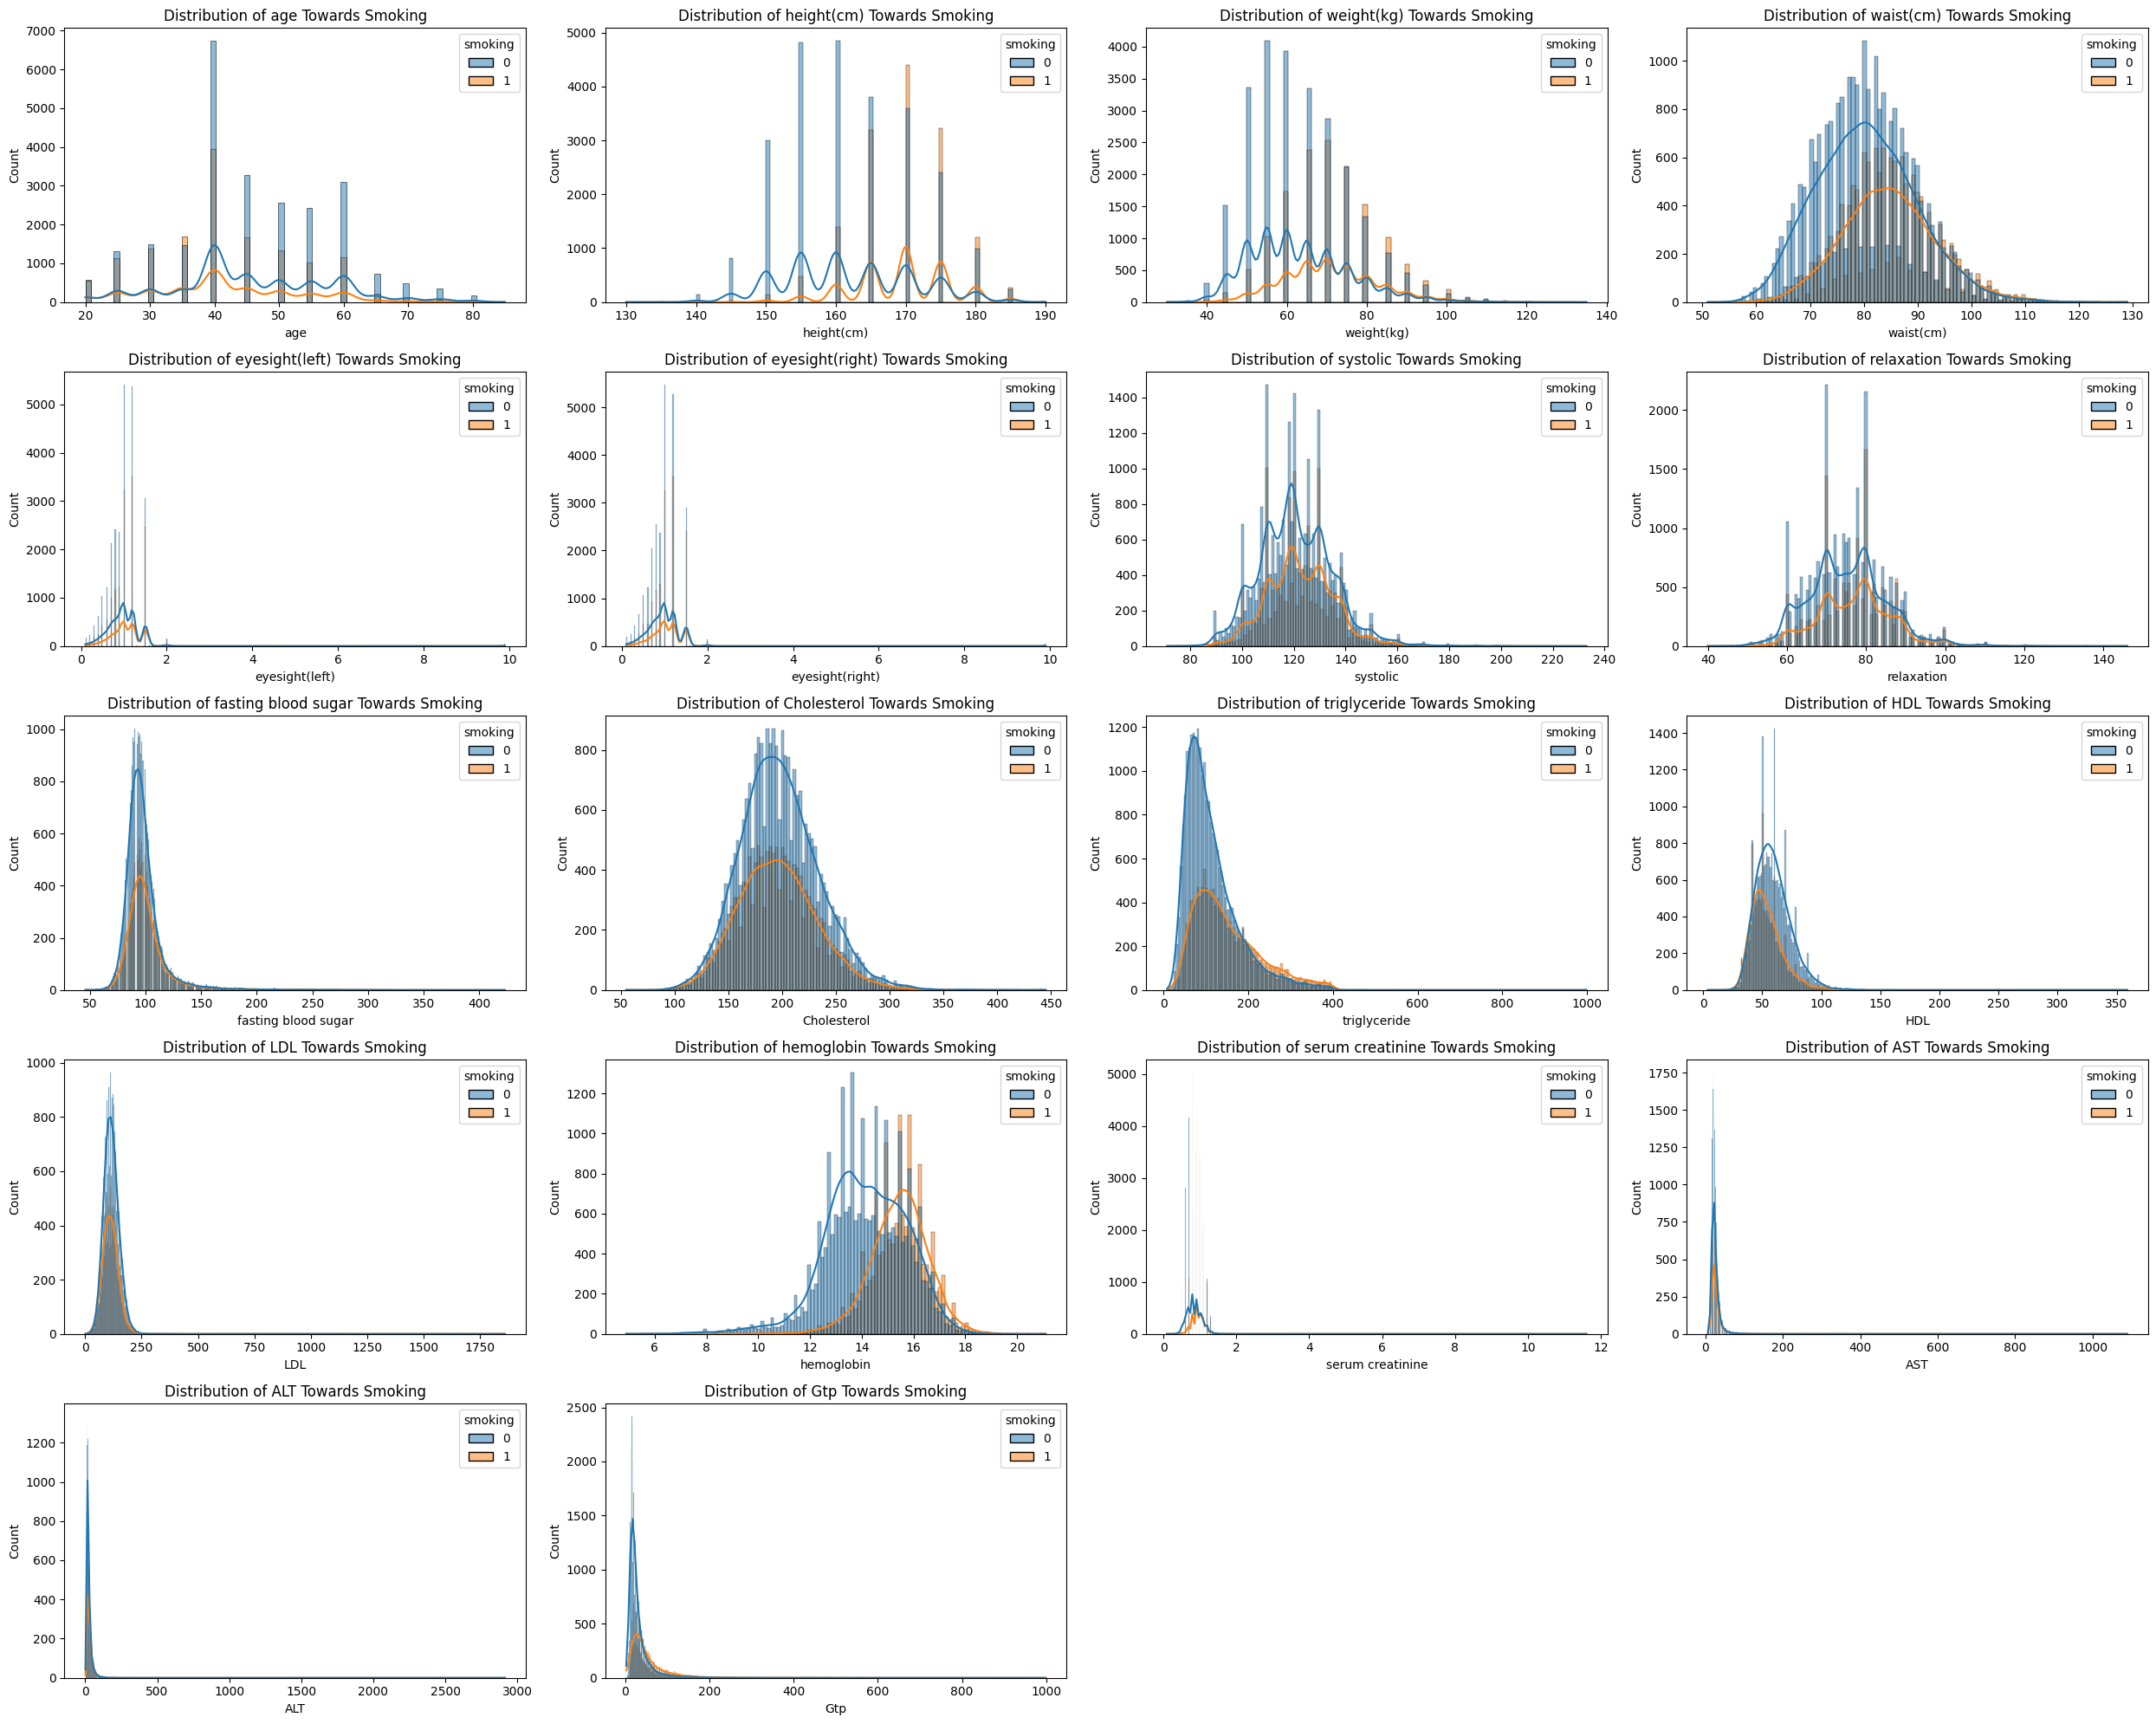

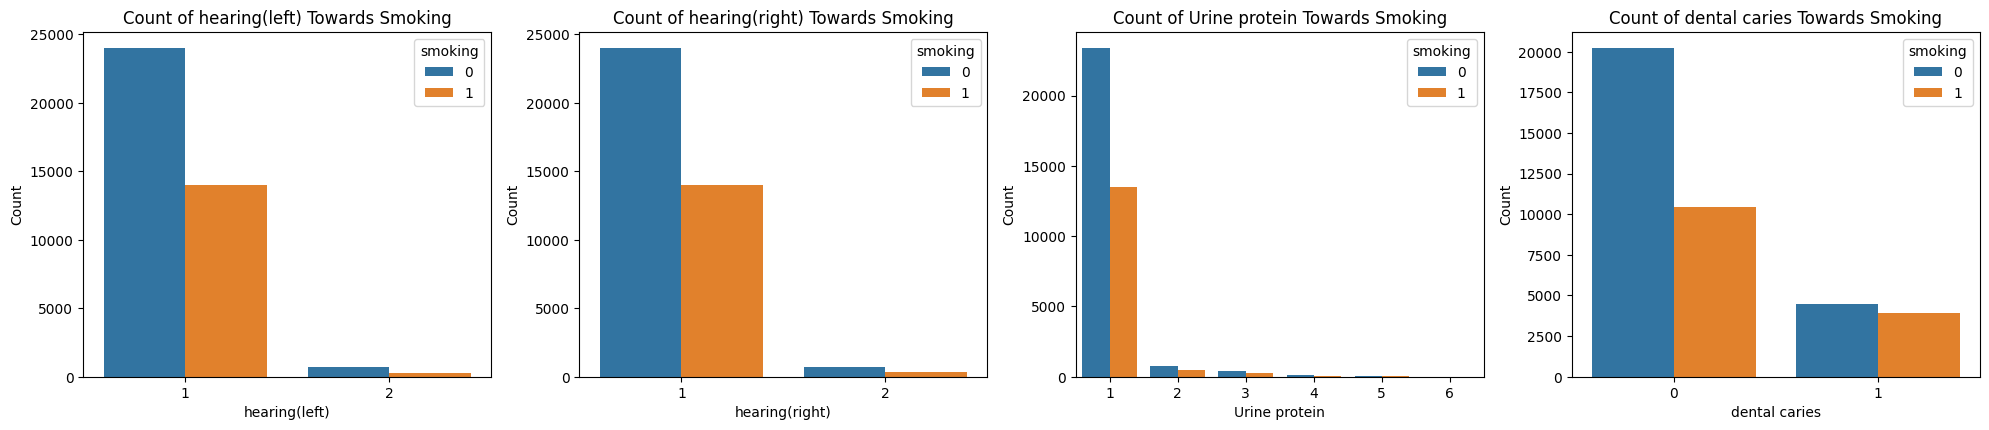

In [ ]:
# Lihat Distribusi All Variables Terhadap smoking
num_cols = [
    'age', 'height(cm)', 'weight(kg)', 'waist(cm)', 'eyesight(left)',
    'eyesight(right)', 'systolic', 'relaxation', 'fasting blood sugar',
    'Cholesterol', 'triglyceride', 'HDL', 'LDL', 'hemoglobin',
    'serum creatinine', 'AST', 'ALT', 'Gtp'
]

cat_cols = ['hearing(left)', 'hearing(right)', 'Urine protein', 'dental caries']

# plotting numerik
n_num = len(num_cols)
rows_num = (n_num // 4) + 1

fig, axes = plt.subplots(rows_num, 4, figsize=(25, rows_num*4))
axes = axes.flatten()

for idx, col in enumerate(num_cols):
    ax = axes[idx]
    sns.histplot(data=df_raw, x=col, hue='smoking', kde=True, ax=ax)
    ax.set_title(f'Distribution of {col} Towards Smoking')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')

# hapus sisa subplot kosong
for i in range(len(num_cols), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()


# plotting kategorikal
n_cat = len(cat_cols)
rows_cat = (n_cat // 4) + 1

fig, axes = plt.subplots(rows_cat, 4, figsize=(20, rows_cat*4))
axes = axes.flatten()

for idx, col in enumerate(cat_cols):
    ax = axes[idx]
    sns.countplot(data=df_raw, x=col, hue='smoking', ax=ax)
    ax.set_title(f'Count of {col} Towards Smoking')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')

for i in range(len(cat_cols), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

In [ ]:
# Cek Missing Value  -> No Missing Value
df_raw.isnull().sum()

,0
age,0
height(cm),0
weight(kg),0
waist(cm),0
eyesight(left),0
eyesight(right),0
hearing(left),0
hearing(right),0
systolic,0
relaxation,0


In [ ]:
# Cek Duplicate Row -> ada 5517 row
df_raw.duplicated().sum()

np.int64(5517)

In [ ]:
# Hapus duplicate
df_raw.drop_duplicates(inplace = True)

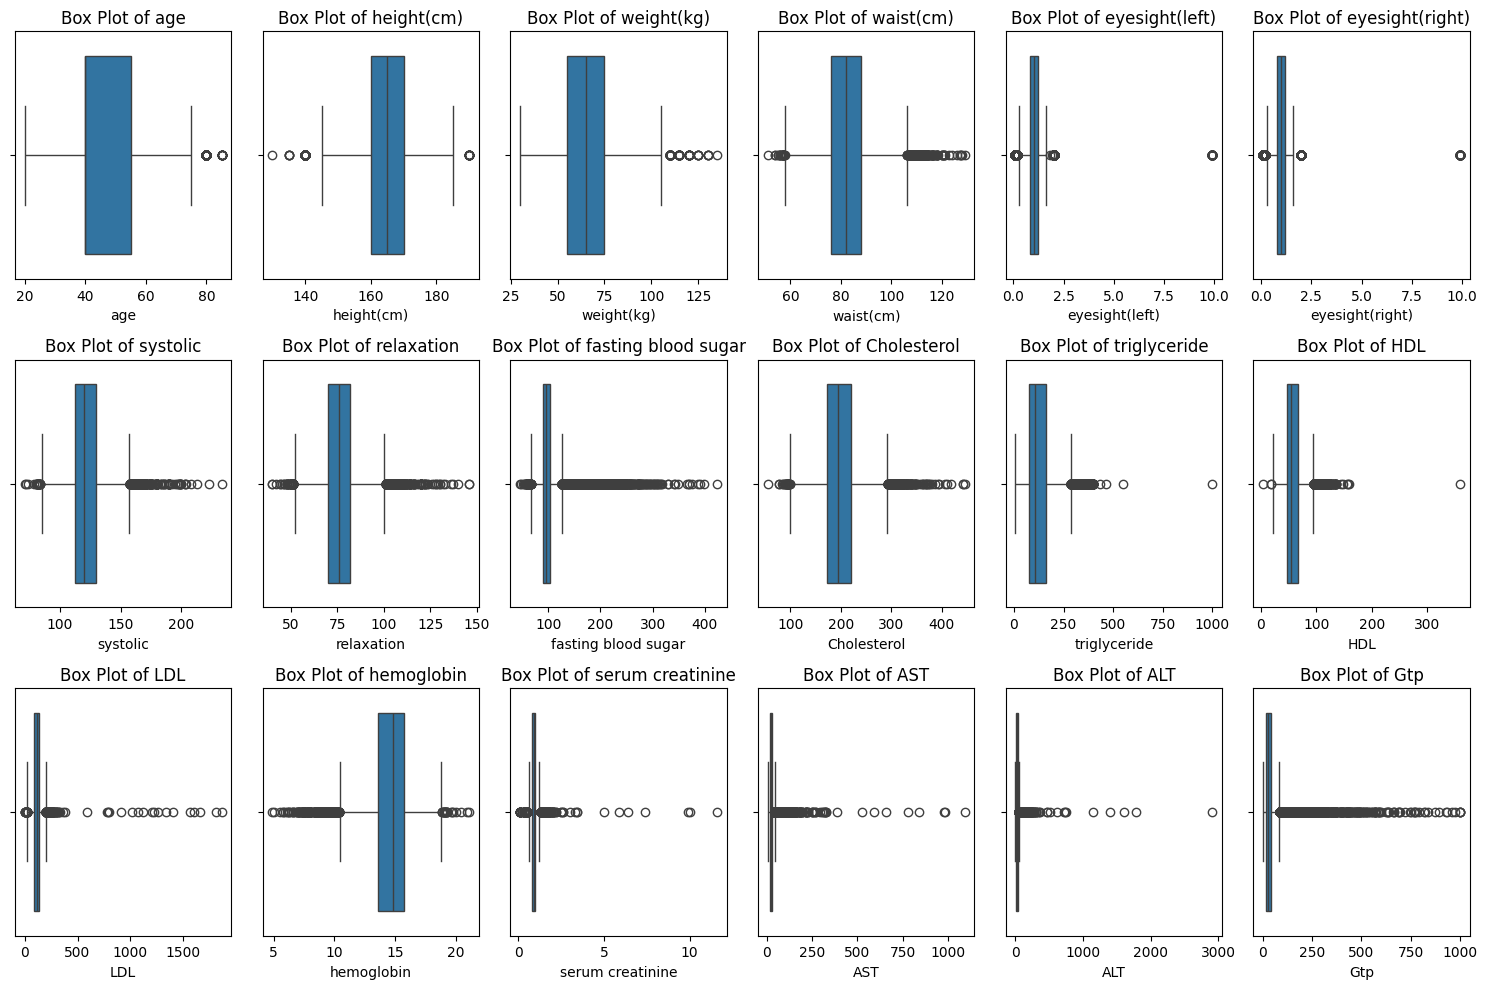

In [ ]:
# Detect Outliers
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols):
    plt.subplot(3, 6, i+1)
    sns.boxplot(x=df_raw[col])
    plt.title(f'Box Plot of {col}')
plt.tight_layout()
plt.show()

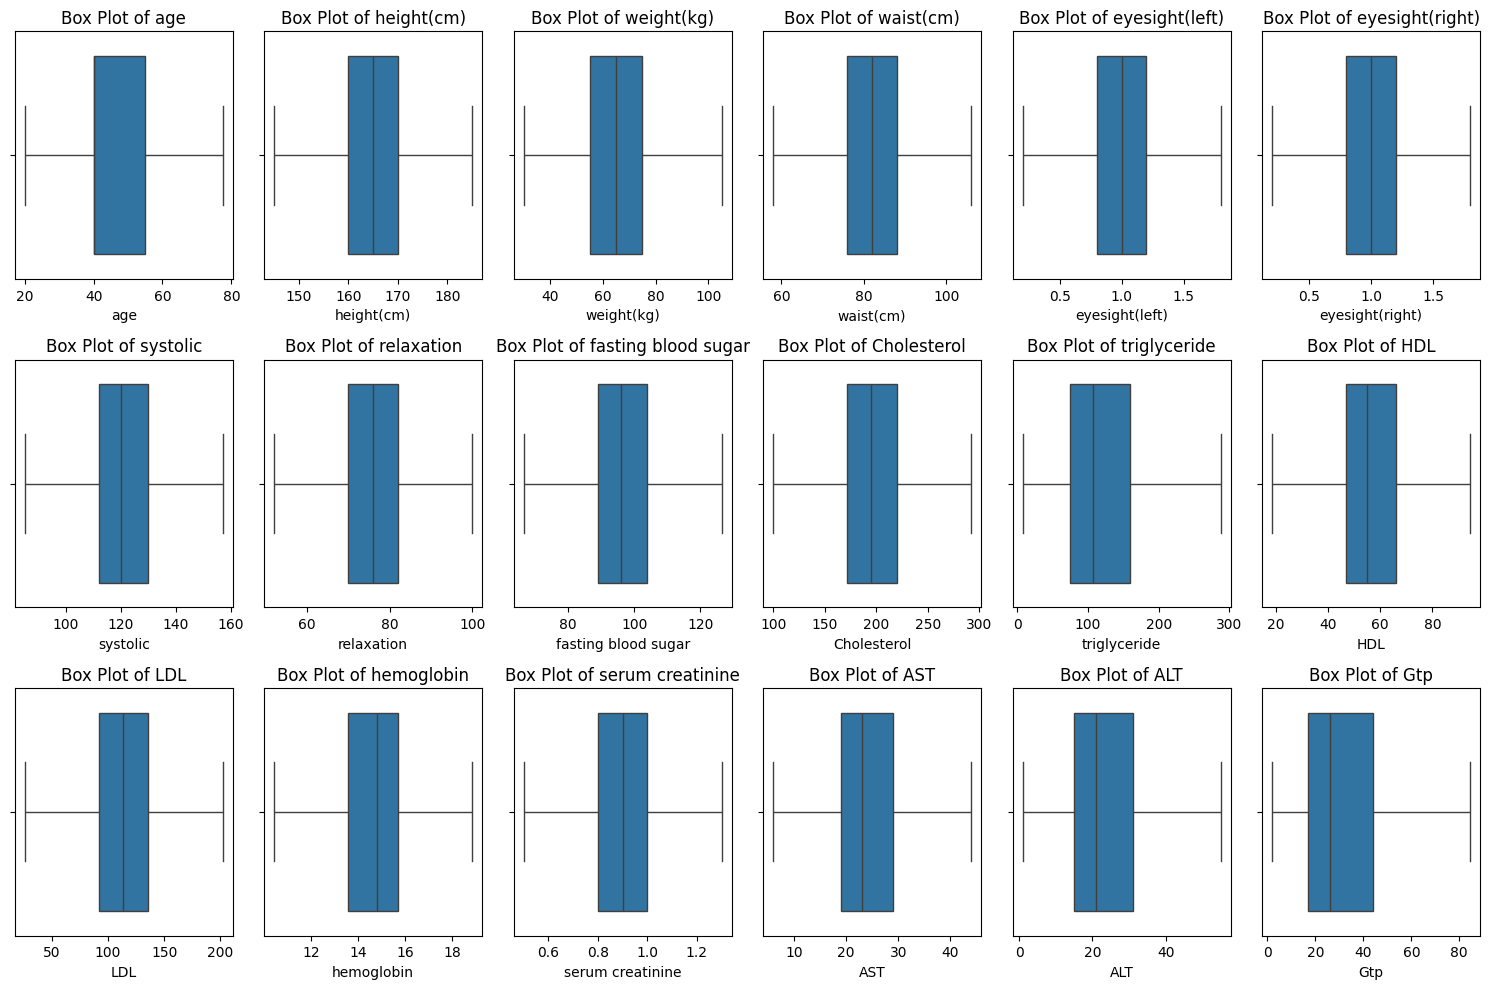

In [ ]:
# Handling outliers using IQR
def handling_outliers(df, col):
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    upper_bound = q3 + 1.5 * iqr
    lower_bound = q1 - 1.5 * iqr
    df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])
    df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
    return df

for col in num_cols:
    df_raw = handling_outliers(df_raw, col)

# Cek lagi
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols):
    plt.subplot(3, 6, i+1)
    sns.boxplot(x=df_raw[col])
    plt.title(f'Box Plot of {col}')
plt.tight_layout()
plt.show()


In [ ]:
# One-Hot Encoding (Categorical Variables)
from sklearn.preprocessing import LabelEncoder
label_encoders = {}
for col in df_raw.select_dtypes(include=['object']).columns:
    label = LabelEncoder()
    df_raw[col] = label.fit_transform(df_raw[col])
    label_encoders[col] = label

In [ ]:
df_raw.head()

,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),systolic,relaxation,...,HDL,LDL,hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,dental caries,smoking
0,35.0,170.0,85.0,97.0,0.9,0.9,1,1,118.0,78.0,...,70.0,142.0,18.85,1,1.0,44.0,55.0,84.5,1,1
1,20.0,175.0,105.0,106.0,0.7,0.9,1,1,119.0,79.0,...,71.0,114.0,15.90,1,1.1,19.0,25.0,30.0,1,0
2,45.0,155.0,65.0,86.0,0.9,0.9,1,1,110.0,80.0,...,57.0,112.0,13.70,3,0.6,44.0,55.0,84.5,0,0
3,45.0,165.0,80.0,94.0,0.8,0.7,1,1,157.0,88.0,...,46.0,91.0,16.90,1,0.9,32.0,36.0,36.0,0,0
4,20.0,165.0,60.0,81.0,1.5,0.2,1,1,109.0,64.0,...,47.0,92.0,14.90,1,1.2,26.0,28.0,15.0,0,0


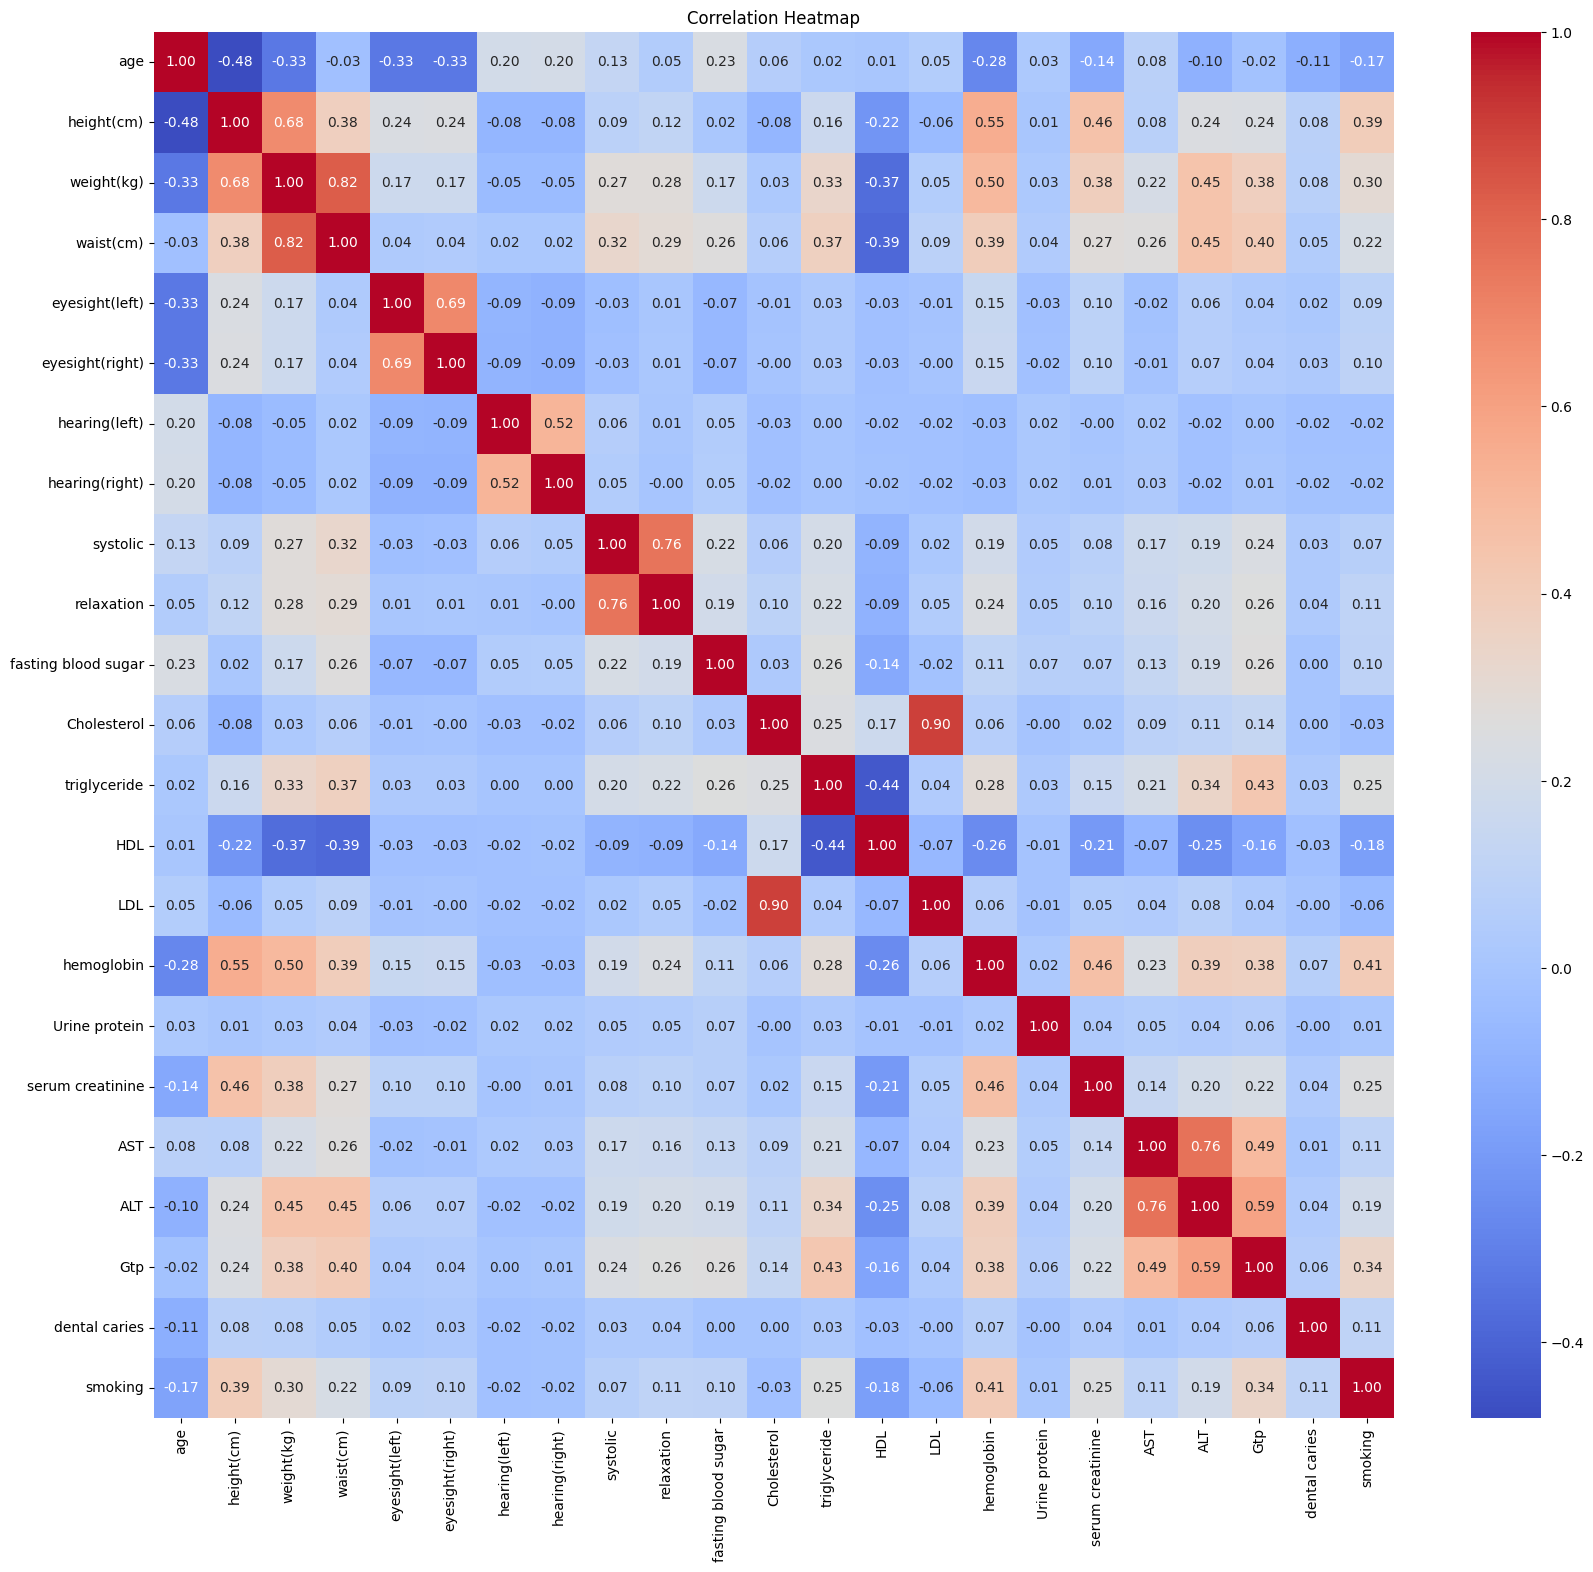

In [ ]:
#Cek korelasi
plt.figure(figsize=(20,18))
sns.heatmap(df_raw.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

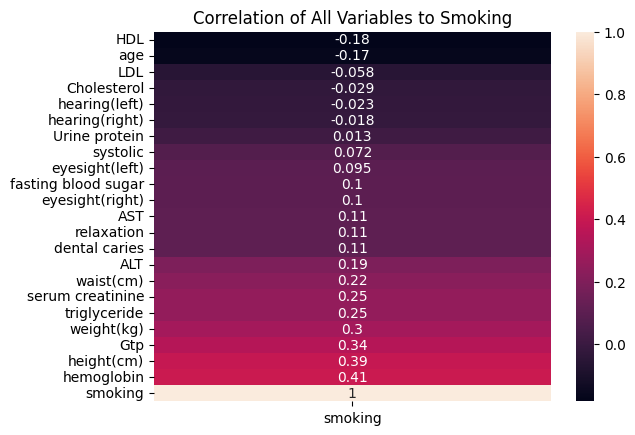

In [ ]:
sns.heatmap(df_raw.corr()[['smoking']].sort_values(by='smoking'), annot=True)
plt.title('Correlation of All Variables to Smoking')
plt.show()

In [ ]:
# Cek imbalance smoking data
df_raw['smoking'].value_counts()

,count
smoking,
0,21209
1,12258


Text(0.5, 1.0, 'Smoking Class Distribution')

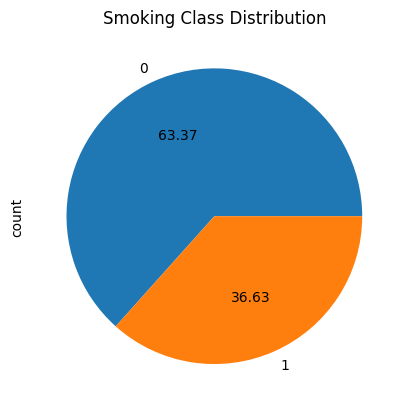

In [ ]:
df_raw['smoking'].value_counts().plot.pie(autopct='%.2f')
plt.title('Smoking Class Distribution')

# hanya 36.63% dari data yang positif smoking

In [ ]:
# Handle imbalanced with downsampling karena jumlah data minority class masih tergolong banyak

# Pisain majority and minority classes
df_majority = df_raw[df_raw.smoking == 0]
df_minority = df_raw[df_raw.smoking == 1]

# Downsample majority class
df_majority_downsampled = df_majority.sample(len(df_minority), random_state=42)

# Gabungin minority class & downsampled majority class
df_downsampled = pd.concat([df_majority_downsampled, df_minority])
df_downsampled = df_downsampled.sample(frac=1, random_state=42).reset_index(drop=True)

In [ ]:
# Memisahkan features dan target (smoking)
from sklearn.model_selection import train_test_split

X = df_downsampled.drop('smoking', axis=1)
y = df_downsampled['smoking']

# Split data: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
# Scaling the downsampled data
from sklearn.preprocessing import StandardScaler
scaler_downsampled = StandardScaler()
X_train = scaler_downsampled.fit_transform(X_train)
X_test = scaler_downsampled.transform(X_test)

print("Original dataset shape:", df_raw.shape)
print("Downsampled dataset shape:", df_downsampled.shape)
print("Downsampled training features shape:", X_train.shape)
print("Downsampled testing features shape:", X_test.shape)
print("Downsampled training target shape:", y_train.shape)
print("Downsampled testing target shape:", y_test.shape)
print("\nDownsampled target distribution:\n", y.value_counts())

Original dataset shape: (33467, 23)
Downsampled dataset shape: (24516, 23)
Downsampled training features shape: (19612, 22)
Downsampled testing features shape: (4904, 22)
Downsampled training target shape: (19612,)
Downsampled testing target shape: (4904,)

Downsampled target distribution:
 smoking
1    12258
0    12258
Name: count, dtype: int64


**Modeling**

Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay

In [ ]:
LR_model = LogisticRegression(class_weight='balanced', random_state=42)
LR_model.fit(X_train, y_train)

# Predict
LR_pred = LR_model.predict(X_test)
LR_prob = LR_model.predict_proba(X_test)[:, 1]

# Evaluation
print(classification_report(y_test, LR_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, LR_pred))
print("\nROC-AUC Score:", roc_auc_score(y_test, LR_prob))


              precision    recall  f1-score   support

           0       0.76      0.70      0.73      2452
           1       0.72      0.78      0.75      2452

    accuracy                           0.74      4904
   macro avg       0.74      0.74      0.74      4904
weighted avg       0.74      0.74      0.74      4904

Confusion Matrix:
 [[1707  745]
 [ 548 1904]]

ROC-AUC Score: 0.8074237430442639


Logistic Regression Tuning

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
param_grid = {
    'C': [50, 100, 200],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga']
}

# Grid Search
grid_lr = GridSearchCV(LogisticRegression(), param_grid, scoring='roc_auc', n_jobs=-1)
grid_lr.fit(X_train, y_train)

# Best result
print("Best Parameters:", grid_lr.best_params_)
print("Best ROC-AUC Score (CV):", grid_lr.best_score_)

#Evaluation
best_lr = grid_lr.best_estimator_
lr_pred_tuned = best_lr.predict(X_test)
lr_prob_tuned = best_lr.predict_proba(X_test)[:, 1]

print("\nClassification Report:")
print(classification_report(y_test, lr_pred_tuned))
print("Confusion Matrix:\n", confusion_matrix(y_test, lr_pred_tuned))
print("\nROC-AUC Score (Test):", roc_auc_score(y_test, lr_prob_tuned))

Best Parameters: {'C': 50, 'penalty': 'l1', 'solver': 'liblinear'}
Best ROC-AUC Score (CV): 0.817779282940422

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.70      0.73      2452
           1       0.72      0.78      0.75      2452

    accuracy                           0.74      4904
   macro avg       0.74      0.74      0.74      4904
weighted avg       0.74      0.74      0.74      4904

Confusion Matrix:
 [[1709  743]
 [ 548 1904]]

ROC-AUC Score (Test): 0.807410603322786


Logistic Regression Threshold Tuning

In [ ]:
y_prob = grid_lr.predict_proba(X_test)[:, 1]
y_pred_custom = (y_prob >= 0.4).astype(int)
print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       0.83      0.61      0.71      2452
           1       0.69      0.88      0.78      2452

    accuracy                           0.75      4904
   macro avg       0.76      0.75      0.74      4904
weighted avg       0.76      0.75      0.74      4904



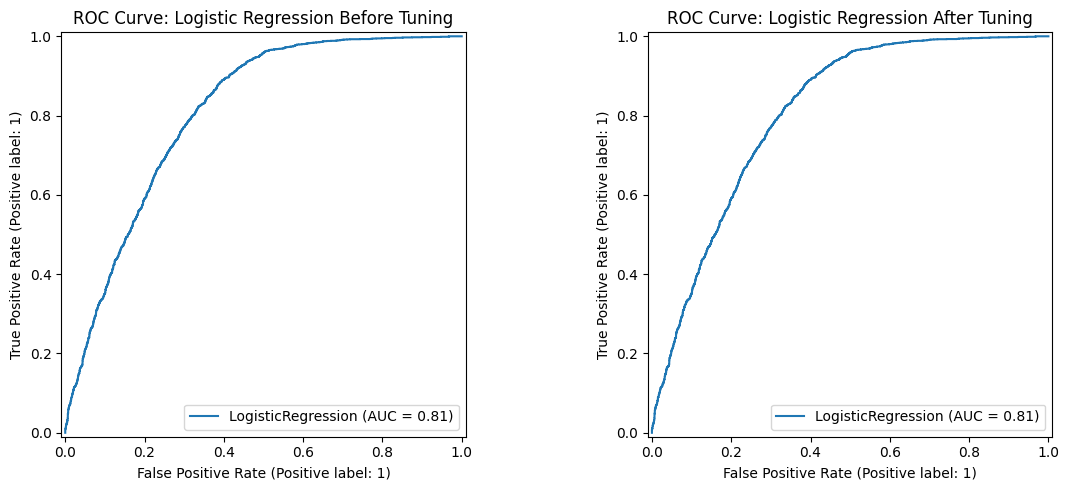

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

#Before tuning
RocCurveDisplay.from_estimator(LR_model, X_test, y_test, ax=axes[0])
axes[0].set_title("ROC Curve: Logistic Regression Before Tuning")

# After tuning
RocCurveDisplay.from_estimator(grid_lr.best_estimator_, X_test, y_test, ax=axes[1])
axes[1].set_title("ROC Curve: Logistic Regression After Tuning")

plt.tight_layout()
plt.show()

Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, rf_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, rf_pred))
print("\nROC-AUC Score:\n", roc_auc_score(y_test, rf_prob))

              precision    recall  f1-score   support

           0       0.80      0.67      0.73      2452
           1       0.72      0.83      0.77      2452

    accuracy                           0.75      4904
   macro avg       0.76      0.75      0.75      4904
weighted avg       0.76      0.75      0.75      4904

Confusion Matrix:
 [[1640  812]
 [ 410 2042]]

ROC-AUC Score:
 0.8183642244304347


Random Forest Tuning

In [ ]:
from sklearn.metrics import f1_score

thresholds = np.arange(0.01, 1.0, 0.01)
f1_scores = []

for t in thresholds:
    y_pred = (rf_prob >= t).astype(int)
    f1 = f1_score(y_test, y_pred, pos_label=1)
    f1_scores.append(f1)

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print(f"Best Threshold: {best_threshold:.2f}")
print(f"Best F1 Score (class 1): {best_f1:.4f}")


Best Threshold: 0.41
Best F1 Score (class 1): 0.7870


In [ ]:
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt'],
}

#grid search
grid_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid_rf,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)
grid_rf.fit(X_train, y_train)

# Best result
print("Best Parameters:", grid_rf.best_params_)
print("Best ROC-AUC Score (CV):", grid_rf.best_score_)

#evaluation
rf_best = grid_rf.best_estimator_
rf_pred_tuned = rf_best.predict(X_test)
rf_prob_tuned = rf_best.predict_proba(X_test)[:, 1]
rf_pred_custom = (rf_prob_tuned >= 0.2).astype(int)

print(classification_report(y_test, rf_pred_custom))
print("Confusion Matrix:\n", confusion_matrix(y_test, rf_pred_custom))
print("\nROC-AUC Score:", roc_auc_score(y_test, rf_prob_tuned))

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best Parameters: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Best ROC-AUC Score (CV): 0.8267564504125691
              precision    recall  f1-score   support

           0       0.95      0.42      0.58      2452
           1       0.63      0.98      0.76      2452

    accuracy                           0.70      4904
   macro avg       0.79      0.70      0.67      4904
weighted avg       0.79      0.70      0.67      4904

Confusion Matrix:
 [[1030 1422]
 [  55 2397]]
ROC-AUC Score: 0.823960165686898


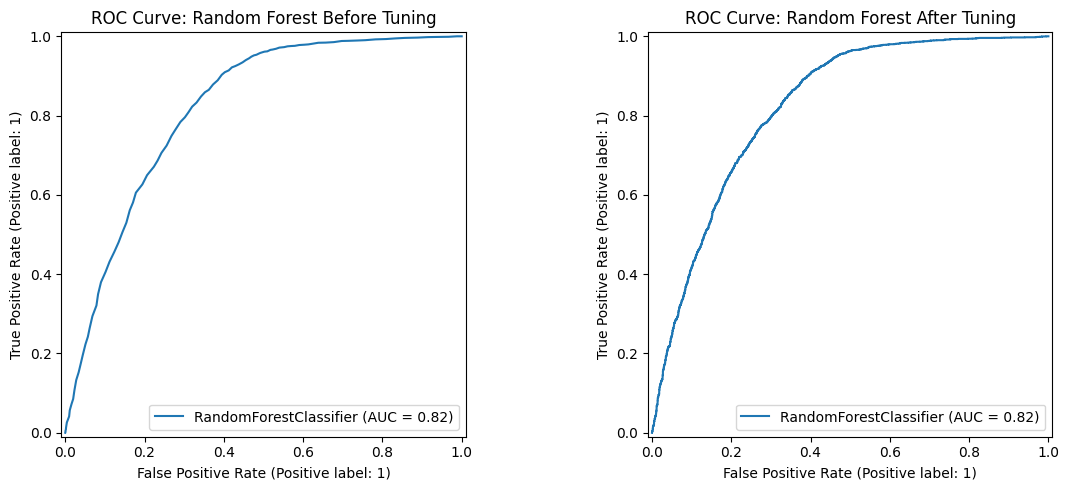

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

#Before tuning
RocCurveDisplay.from_estimator(rf_model, X_test, y_test, ax=axes[0])
axes[0].set_title("ROC Curve: Random Forest Before Tuning")

# After tuning
RocCurveDisplay.from_estimator(grid_rf.best_estimator_, X_test, y_test, ax=axes[1])
axes[1].set_title("ROC Curve: Random Forest After Tuning")

plt.tight_layout()
plt.show()

XGBoost

In [ ]:
from xgboost import XGBClassifier

In [ ]:
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, xgb_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, xgb_pred))
print("\nROC-AUC Score:\n", roc_auc_score(y_test, xgb_prob))

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [00:53:07] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


              precision    recall  f1-score   support

           0       0.77      0.68      0.72      2452
           1       0.72      0.80      0.76      2452

    accuracy                           0.74      4904
   macro avg       0.74      0.74      0.74      4904
weighted avg       0.74      0.74      0.74      4904

Confusion Matrix:
 [[1671  781]
 [ 491 1961]]

ROC-AUC Score:
 0.8136894774449196


XGB Tuning

In [ ]:
param_grid_xgb = {
    'n_estimators': [300, 200],
    'max_depth': [3, 6],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 0.7],
    'colsample_bytree': [0.8, 0.7]
}

#grid search
grid_xgb = GridSearchCV(
    estimator=XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    param_grid=param_grid_xgb,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)
grid_xgb.fit(X_train, y_train)

# Best result
print("Best Parameters:", grid_xgb.best_params_)
print("Best ROC-AUC Score (CV):", grid_xgb.best_score_)

#evaluation
xgb_best = grid_xgb.best_estimator_
xgb_pred_tuned = xgb_best.predict(X_test)
xgb_prob_tuned = xgb_best.predict_proba(X_test)[:, 1]

print(classification_report(y_test, xgb_pred_tuned))
print("Confusion Matrix:\n", confusion_matrix(y_test, xgb_pred_tuned))
print("\nROC-AUC Score:", roc_auc_score(y_test, xgb_prob_tuned))

Fitting 5 folds for each of 32 candidates, totalling 160 fits


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [00:56:02] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
Best ROC-AUC Score (CV): 0.8325883827428532
              precision    recall  f1-score   support

           0       0.81      0.67      0.73      2452
           1       0.72      0.85      0.78      2452

    accuracy                           0.76      4904
   macro avg       0.77      0.76      0.76      4904
weighted avg       0.77      0.76      0.76      4904

Confusion Matrix:
 [[1638  814]
 [ 372 2080]]

ROC-AUC Score: 0.8295989357823557


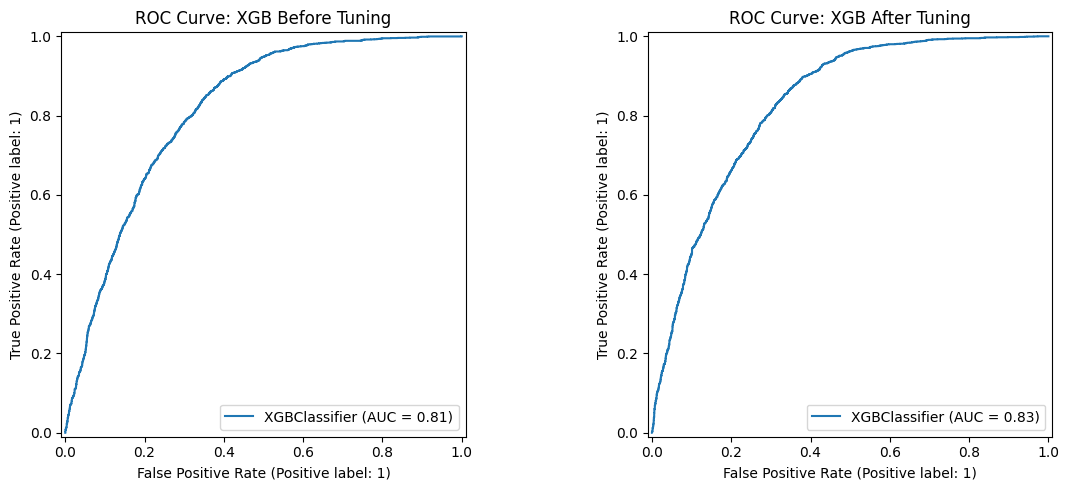

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

#Before tuning
RocCurveDisplay.from_estimator(xgb_model, X_test, y_test, ax=axes[0])
axes[0].set_title("ROC Curve: XGB Before Tuning")

# After tuning
RocCurveDisplay.from_estimator(grid_xgb.best_estimator_, X_test, y_test, ax=axes[1])
axes[1].set_title("ROC Curve: XGB After Tuning")

plt.tight_layout()
plt.show()

LGBM

In [ ]:
from lightgbm import LGBMClassifier

In [ ]:
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Langsung pake LGBMClassifier dengan parameter default
lgb_model = LGBMClassifier(random_state=42)
lgb_model.fit(X_train, y_train)

# Prediksi
lgb_prob = lgb_model.predict_proba(X_test)[:, 1]
lgb_pred_custom = (lgb_prob >= 0.5).astype(int)

# Evaluasi
print("\nClassification Report:\n", classification_report(y_test, lgb_pred_custom))
print("Confusion Matrix:\n", confusion_matrix(y_test, lgb_pred_custom))
print("\nROC-AUC Score (Test):", roc_auc_score(y_test, lgb_prob))

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Number of positive: 9806, number of negative: 9806
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002354 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1481
[LightGBM] [Info] Number of data points in the train set: 19612, number of used features: 22
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.67      0.73      2452
           1       0.72      0.84      0.77      2452

    accuracy                           0.76      4904
   macro avg       0.76      0.76      0.75      4904
weighted avg       0.76      0.76      0.75      4904

Confusion Matrix:
 [[1643  809]
 [ 389 2063]]

ROC-AUC Score (Test): 0.830296671625387


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


LGBM Tuning

In [ ]:
param_grid_lgb = {
    'n_estimators': [100],
    'max_depth': [5, 10],
    'learning_rate': [0.05, 0.1],
    'num_leaves': [31],
    'min_child_samples': [10],
    'subsample': [0.8],
    'colsample_bytree': [1.0]
}

# Grid search
grid_lgb = GridSearchCV(
    estimator=LGBMClassifier(random_state=42),
    param_grid=param_grid_lgb,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)
grid_lgb.fit(X_train, y_train)

# Best result
print("Best Parameters:", grid_lgb.best_params_)
print("Best ROC-AUC Score (CV):", grid_lgb.best_score_)

# Evaluation
lgb_best = grid_lgb.best_estimator_
lgb_pred = lgb_best.predict(X_test)
lgb_prob = lgb_best.predict_proba(X_test)[:, 1]

print("Classification Report:\n", classification_report(y_test, lgb_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, lgb_pred))
print("ROC-AUC Score (Test):", roc_auc_score(y_test, lgb_prob))

Fitting 5 folds for each of 4 candidates, totalling 20 fits


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Number of positive: 9806, number of negative: 9806
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002094 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1481
[LightGBM] [Info] Number of data points in the train set: 19612, number of used features: 22
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posit

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


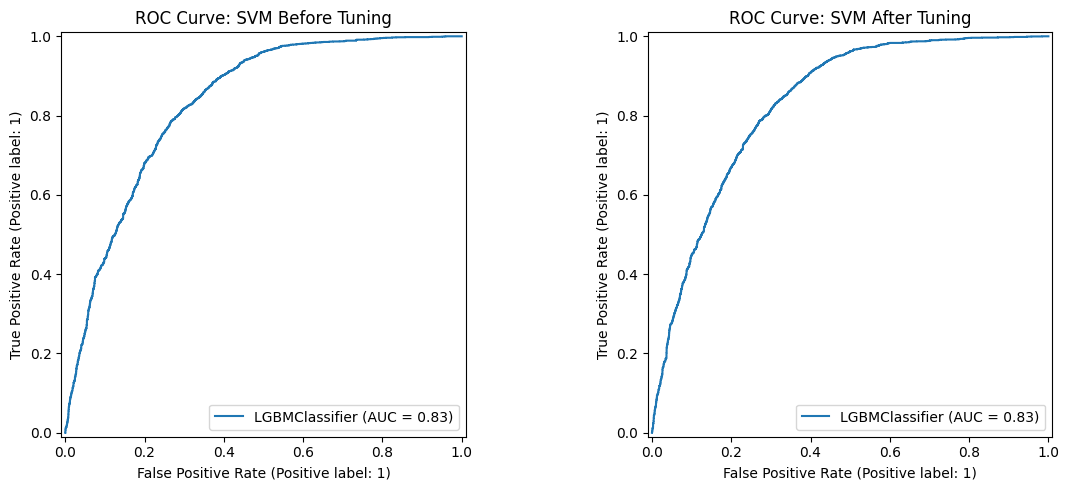

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

#Before tuning
RocCurveDisplay.from_estimator(lgb_model, X_test, y_test, ax=axes[0])
axes[0].set_title("ROC Curve: SVM Before Tuning")

# After tuning
RocCurveDisplay.from_estimator(grid_lgb.best_estimator_, X_test, y_test, ax=axes[1])
axes[1].set_title("ROC Curve: SVM After Tuning")

plt.tight_layout()
plt.show()

KNN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
knn_model = KNeighborsClassifier()
knn_model.fit(X_train, y_train)
knn_pred = knn_model.predict(X_test)
knn_prob = knn_model.predict_proba(X_test)[:, 1]

# Evaluasi
print("Classification Report:\n", classification_report(y_test, knn_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, knn_pred))
print("\nROC-AUC Score:", roc_auc_score(y_test, knn_prob))

Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.67      0.70      2452
           1       0.70      0.75      0.72      2452

    accuracy                           0.71      4904
   macro avg       0.71      0.71      0.71      4904
weighted avg       0.71      0.71      0.71      4904

Confusion Matrix:
 [[1650  802]
 [ 614 1838]]

ROC-AUC Score: 0.7664595802208272


KNN Tuning

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Parameter grid untuk KNN
param_grid_knn = {
    'n_neighbors': [3, 5],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

# Cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Grid search
grid_knn = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=param_grid_knn,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)
grid_knn.fit(X_train, y_train)

# Best result
print("Best Parameters:", grid_knn.best_params_)
print("Best ROC-AUC Score (CV):", grid_knn.best_score_)

# Evaluation
knn_best = grid_knn.best_estimator_
knn_pred_tuned = knn_best.predict(X_test)
knn_prob_tuned = knn_best.predict_proba(X_test)[:, 1]
knn_pred_custom = (knn_prob_tuned >= 0.2).astype(int)

print(classification_report(y_test, knn_pred_custom))
print("Confusion Matrix:\n", confusion_matrix(y_test, knn_pred_custom))
print("\nROC-AUC Score:", roc_auc_score(y_test, knn_prob_tuned))

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best Parameters: {'metric': 'euclidean', 'n_neighbors': 5, 'weights': 'uniform'}
Best ROC-AUC Score (CV): 0.7706138064746165
              precision    recall  f1-score   support

           0       0.92      0.33      0.48      2452
           1       0.59      0.97      0.73      2452

    accuracy                           0.65      4904
   macro avg       0.75      0.65      0.61      4904
weighted avg       0.75      0.65      0.61      4904

Confusion Matrix:
 [[ 804 1648]
 [  73 2379]]

ROC-AUC Score: 0.7664595802208272


In [ ]:
from sklearn.ensemble import StackingClassifier

stacked = StackingClassifier(
    estimators=[
        ('lr', LogisticRegression()),
        ('rf', RandomForestClassifier(random_state=42)),
        ('lgbm', LGBMClassifier(random_state=42))
    ],
    final_estimator=LogisticRegression()
)

stacked.fit(X_train, y_train)
y_pred_stack = stacked.predict(X_test)
y_prob_stack = stacked.predict_proba(X_test)[:, 1]
print(classification_report(y_test, y_pred_stack))
print("\nROC AUC:", roc_auc_score(y_test, y_prob_stack))

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Number of positive: 9806, number of negative: 9806
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002027 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1481
[LightGBM] [Info] Number of data points in the train set: 19612, number of used features: 22
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Number of positive: 7844, number of negative: 7845
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001784 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1477
[LightGBM] [Info] Number of data points in the train set: 15689, number of used features: 22
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499968 -> initscore=-0.000127
[LightGBM] [Info] Start training from score -0.000127


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


...

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Number of positive: 7845, number of negative: 7845
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001761 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1474
[LightGBM] [Info] Number of data points in the train set: 15690, number of used features: 22
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


              precision    recall  f1-score   support

           0       0.80      0.68      0.74      2452
           1       0.72      0.82      0.77      2452

    accuracy                           0.75      4904
   macro avg       0.76      0.75      0.75      4904
weighted avg       0.76      0.75      0.75      4904


ROC AUC: 0.8280522741365041


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [ ]:
#soft voting
from sklearn.ensemble import VotingClassifier

estimators = [('LR', LogisticRegression(random_state=100)), ('RF', RandomForestClassifier(random_state=100)), ('XGB', XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=100))]
voting_model_soft = VotingClassifier(estimators = estimators, voting='soft')
voting_model_soft.fit(X_train, y_train)

prediction = voting_model_soft.predict(X_test)

print(classification_report(prediction, y_test))

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [00:57:30] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


              precision    recall  f1-score   support

           0       0.68      0.80      0.73      2078
           1       0.83      0.72      0.77      2826

    accuracy                           0.75      4904
   macro avg       0.75      0.76      0.75      4904
weighted avg       0.77      0.75      0.76      4904



In [ ]:
#hard voting
from sklearn.ensemble import VotingClassifier

estimators = [('LR', LogisticRegression(random_state=100)), ('RF', RandomForestClassifier(random_state=100)), ('XGB', XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=100))]

voting_model_hard = VotingClassifier(estimators = estimators, voting='hard')
voting_model_hard.fit(X_train, y_train)

prediction = voting_model_hard.predict(X_test)

print(classification_report(prediction, y_test))

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [00:57:36] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


              precision    recall  f1-score   support

           0       0.68      0.79      0.73      2093
           1       0.82      0.72      0.77      2811

    accuracy                           0.75      4904
   macro avg       0.75      0.76      0.75      4904
weighted avg       0.76      0.75      0.75      4904



In [ ]:
#adaboost
from sklearn.ensemble import AdaBoostClassifier

adaboost_model = AdaBoostClassifier(n_estimators=10, estimator=RandomForestClassifier())
adaboost_model.fit(X_train, y_train)
prediction = adaboost_model.predict(X_test)
print(classification_report(prediction, y_test))

              precision    recall  f1-score   support

           0       0.66      0.80      0.73      2035
           1       0.83      0.71      0.77      2869

    accuracy                           0.75      4904
   macro avg       0.75      0.76      0.75      4904
weighted avg       0.76      0.75      0.75      4904



/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


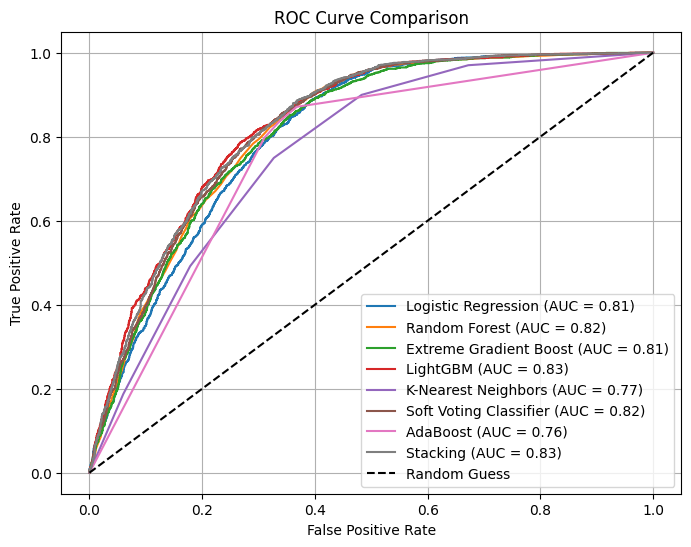

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

models = {
    'Logistic Regression': LR_model.predict_proba(X_test)[:, 1],
    'Random Forest': rf_model.predict_proba(X_test)[:, 1],
    'Extreme Gradient Boost': xgb_model.predict_proba(X_test)[:, 1],
    'LightGBM': lgb_model.predict_proba(X_test)[:, 1],
    'K-Nearest Neighbors': knn_model.predict_proba(X_test)[:, 1],
    'Soft Voting Classifier': voting_model_soft.predict_proba(X_test)[:, 1],
    'AdaBoost': adaboost_model.predict_proba(X_test)[:, 1],
    'Stacking': stacked.predict_proba(X_test)[:, 1]
}

plt.figure(figsize=(8, 6))

for name, y_prob in models.items():
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.2f})')

# Garis baseline
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


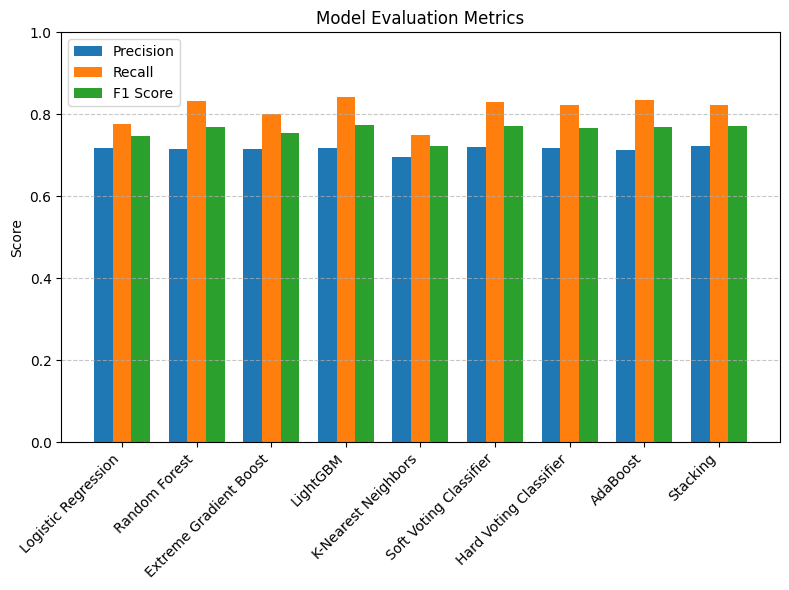

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score


predictions = {
    'Logistic Regression': LR_model.predict(X_test),
    'Random Forest': rf_model.predict(X_test),
    'Extreme Gradient Boost': xgb_model.predict(X_test),
    'LightGBM': lgb_model.predict(X_test),
    'K-Nearest Neighbors': knn_model.predict(X_test),
    'Soft Voting Classifier': voting_model_soft.predict(X_test),
    'Hard Voting Classifier': voting_model_hard.predict(X_test),
    'AdaBoost': adaboost_model.predict(X_test),
    'Stacking': stacked.predict(X_test)
}

# Buat list untuk menyimpan nilai metrik
models = list(predictions.keys())
precision_scores = []
recall_scores = []
f1_scores = []

# Hitung metrik untuk setiap model
for name in models:
    y_pred = predictions[name]
    precision_scores.append(precision_score(y_test, y_pred))
    recall_scores.append(recall_score(y_test, y_pred))
    f1_scores.append(f1_score(y_test, y_pred))

# Plot
x = np.arange(len(models))
width = 0.25

plt.figure(figsize=(8, 6))
plt.bar(x - width, precision_scores, width=width, label='Precision')
plt.bar(x, recall_scores, width=width, label='Recall')
plt.bar(x + width, f1_scores, width=width, label='F1 Score')

plt.xticks(x, models, rotation=45, ha='right')
plt.ylabel('Score')
plt.title('Model Evaluation Metrics')
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()